# Entregável 6: Extração de Atributos do ECG (Feature Extraction)
**Disciplina:** Aquisição de Biossinais
**Equipe:** José Ferreira Lessa e Matheus Rocha Gomes da Silva
**Objetivo:** Transformação de sinais brutos em um dataset de alta dimensão através da extração de atributos temporais, espectrais, morfológicos e não-lineares.


## Introdução e Justificativa
A extração de atributos é a etapa onde traduzimos o conhecimento clínico da cardiologia em variáveis numéricas que podem ser processadas por algoritmos de aprendizado de máquina. 

Neste notebook, implementamos uma **Estratégia Híbrida**: 
1.  **Global (10s)**: Capturamos a dinâmica geral do exame em todas as 12 derivações.
2.  **Local (Batimento)**: Analisamos a morfologia fina de cada ciclo cardíaco e agregamos esses valores (via Mediana e Desvio Padrão) para o nível de registro.

Isso nos permite representar tanto alterações de ritmo (HRV) quanto alterações morfológicas (Isquemias, Hipertrofias) de forma robusta.


## 1. Instalação e Configuração do Ambiente


In [11]:
# Instalação de bibliotecas especializadas para análise de biossinais
#%pip install PyWavelets antropy joblib fastparquet pyarrow -q

import os
import ast
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal as signal
import pywt
import antropy as ant
from scipy.stats import entropy
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from IPython.display import display, Markdown

# Configurações de visualização acadêmica
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

FS = 100
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
np.random.seed(42)


## 2. Carregamento de Sinais e Metadados
Importamos os sinais limpos (D4) e as segmentações (D5) usando **Memory Mapping** para evitar erros de RAM.


In [12]:
# Diretórios de Entrada
DIR_IN_D4 = '../../entregavel-4/outputs/'
DIR_IN_D5 = '../../entregavel-5/outputs/'

# Diretório de Saída
DIR_OUT_D6 = '../outputs/'
FIGS_DIR = '../figuras/'
os.makedirs(DIR_OUT_D6, exist_ok=True)
os.makedirs(FIGS_DIR, exist_ok=True)

print("Carregando bases de dados via Memory Mapping... (Economiza RAM)")
# mmap_mode='r' permite ler o arquivo sem carregá-lo inteiramente na RAM
sinais_10s = np.load(os.path.join(DIR_IN_D4, 'sinais_limpos_100hz.npy'), mmap_mode='r')
batimentos = np.load(os.path.join(DIR_IN_D5, 'batimentos_segmentados.npy'), mmap_mode='r')

df_reg_ids = pd.read_csv(os.path.join(DIR_IN_D5, 'registros_ids.csv'), index_col='ecg_id')
df_beat_ids = pd.read_csv(os.path.join(DIR_IN_D5, 'batimentos_ids.csv'))

print(f"Dataset 10s: {sinais_10s.shape}")
print(f"Dataset Batimentos: {batimentos.shape}")


Carregando bases de dados via Memory Mapping... (Economiza RAM)
Dataset 10s: (21735, 1000, 12)
Dataset Batimentos: (269004, 60, 12)


---
## Seção 1 — Domínio do Tempo (Registro Inteiro)

Extraímos estatísticas descritivas que capturam a distribuição de amplitude e a energia do sinal em todas as 12 derivações.


In [13]:
def extract_time_domain(sig_12l):
    """Calcula estatísticas temporais para as 12 derivações."""
    feats = {}
    for i, lead in enumerate(LEAD_NAMES):
        s = sig_12l[:, i]
        feats[f'time_rms_{lead}'] = np.sqrt(np.mean(s**2))
        feats[f'time_mav_{lead}'] = np.mean(np.abs(s))
        feats[f'time_var_{lead}'] = np.var(s)
        feats[f'time_p2p_{lead}'] = np.ptp(s)
        feats[f'time_zcr_{lead}'] = np.sum(np.diff(np.sign(s)) != 0) / len(s)
        
        # Estatísticas de forma (usando pandas para skew/kurt)
        ser = pd.Series(s)
        feats[f'time_skew_{lead}'] = ser.skew()
        feats[f'time_kurt_{lead}'] = ser.kurt()
    return feats

print("Processando Domínio do Tempo em paralelo...")
time_feats = Parallel(n_jobs=-1)(delayed(extract_time_domain)(s) for s in tqdm(sinais_10s))
df_time = pd.DataFrame(time_feats, index=df_reg_ids.index)
# Limpeza de memória
del time_feats
gc.collect()
display(df_time.head(3))


Processando Domínio do Tempo em paralelo...


  0%|          | 0/21735 [00:00<?, ?it/s]

,time_rms_I,time_mav_I,time_var_I,time_p2p_I,time_zcr_I,time_skew_I,time_kurt_I,time_rms_II,time_mav_II,time_var_II,...,time_zcr_V5,time_skew_V5,time_kurt_V5,time_rms_V6,time_mav_V6,time_var_V6,time_p2p_V6,time_zcr_V6,time_skew_V6,time_kurt_V6
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,0.094907,0.055855,0.009005,0.715472,0.131,3.647302,17.185074,0.078019,0.054225,0.006083,...,0.065,3.156050,11.907948,0.091738,0.059889,0.008411,0.670223,0.059,2.571055,7.625116
2,0.131461,0.085688,0.017279,1.160812,0.046,2.442443,7.090211,0.175857,0.123082,0.030920,...,0.049,4.407525,24.551136,0.172769,0.091348,0.029849,1.357437,0.053,4.415347,24.012783
3,0.119825,0.070933,0.014357,0.963564,0.086,3.720026,17.648897,0.103282,0.067339,0.010665,...,0.067,4.451029,24.381105,0.087308,0.047073,0.007621,0.726200,0.070,4.283570,22.470839


---
## Seção 2 — Domínio da Frequência (PSD via Welch)

Analisamos o conteúdo espectral do ECG. As bandas foram escolhidas para isolar componentes morfológicas (P, QRS, T).


In [14]:
def extract_freq_domain(sig_12l, fs=100):
    """Calcula potência em bandas e descritores espectrais via Welch PSD."""
    feats = {}
    for i, lead in enumerate(LEAD_NAMES):
        s = sig_12l[:, i]
        # Welch com janela de 2.56s (nperseg=256) para boa resolução
        f, psd = signal.welch(s, fs=fs, nperseg=256, noverlap=128)
        
        # Integração em bandas fisiológicas (Regra Trapezoidal)
        feats[f'freq_pt_band_{lead}'] = np.trapz(psd[(f >= 0.5) & (f <= 5)], f[(f >= 0.5) & (f <= 5)])
        feats[f'freq_qrs_band_{lead}'] = np.trapz(psd[(f >= 5) & (f <= 25)], f[(f >= 5) & (f <= 25)])
        feats[f'freq_total_pwr_{lead}'] = np.trapz(psd[(f >= 0.5) & (f <= 40)], f[(f >= 0.5) & (f <= 40)])
        
        # Descritores de forma da PSD
        feats[f'freq_peak_{lead}'] = f[np.argmax(psd)]
        feats[f'freq_median_{lead}'] = f[np.where(np.cumsum(psd) >= np.sum(psd)/2)[0][0]]
        feats[f'freq_centroid_{lead}'] = np.sum(f * psd) / np.sum(psd)
    return feats

print("Processando Domínio da Frequência...")
freq_feats = Parallel(n_jobs=-1)(delayed(extract_freq_domain)(s) for s in tqdm(sinais_10s))
df_freq = pd.DataFrame(freq_feats, index=df_reg_ids.index)
# Limpeza de memória
del freq_feats
gc.collect()
display(df_freq.head(3))


Processando Domínio da Frequência...


  0%|          | 0/21735 [00:00<?, ?it/s]

,freq_pt_band_I,freq_qrs_band_I,freq_total_pwr_I,freq_peak_I,freq_median_I,freq_centroid_I,freq_pt_band_II,freq_qrs_band_II,freq_total_pwr_II,freq_peak_II,...,freq_total_pwr_V5,freq_peak_V5,freq_median_V5,freq_centroid_V5,freq_pt_band_V6,freq_qrs_band_V6,freq_total_pwr_V6,freq_peak_V6,freq_median_V6,freq_centroid_V6
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,0.002816,0.005314,0.008676,3.12500,7.812500,9.777974,0.002418,0.002916,0.005547,3.125000,...,0.007305,3.12500,7.03125,8.119360,0.003563,0.003458,0.007180,3.12500,4.296875,6.368581
2,0.010357,0.005533,0.016894,0.78125,3.125000,6.301521,0.015168,0.011743,0.028779,0.781250,...,0.051313,0.78125,7.81250,10.306411,0.011936,0.018543,0.032843,0.78125,7.031250,9.253792
3,0.004580,0.008088,0.013516,3.12500,7.421875,9.856007,0.003802,0.004815,0.008947,1.171875,...,0.010017,3.12500,9.37500,10.878084,0.002136,0.004632,0.007194,3.12500,7.812500,9.713963


---
## Seção 3 — Morfologia Fina e Variabilidade (HRV)

Trabalhamos agora sobre os **batimentos segmentados**. Extraímos métricas clínicas e agregamos os resultados para o nível do registro.


In [15]:
def extract_morph_per_beat(beat_12l):
    """Extrai morfologia de um único batimento (60 amostras)."""
    feats = {}
    # Focamos nas derivações mais diagnósticas para morfologia: II e V5
    for l_idx, l_name in [(1, 'II'), (10, 'V5')]:
        s = beat_12l[:, l_idx]
        feats[f'morph_r_amp_{l_name}'] = np.max(s)
        # QRS Duration (estimação por cruzamento de limiar 15% do pico)
        peak_idx = np.argmax(s)
        thresh = s[peak_idx] * 0.15
        try:
            qrs_pts = np.where(s > thresh)[0]
            feats[f'morph_qrs_width_{l_name}'] = (qrs_pts[-1] - qrs_pts[0]) * 10 # em ms
        except:
            feats[f'morph_qrs_width_{l_name}'] = 100 # Default fallback
            
        # Segmento ST (Média entre 35-45 amostras - pós-QRS)
        feats[f'morph_st_amp_{l_name}'] = np.mean(s[35:45])
        # Onda T (Pico na janela final)
        feats[f'morph_t_amp_{l_name}'] = np.max(s[40:])
        
    return feats

print("Processando Morfologia Individual dos Batimentos...")
morph_list = Parallel(n_jobs=-1)(delayed(extract_morph_per_beat)(b) for b in tqdm(batimentos))
df_morph_all = pd.DataFrame(morph_list)

# Agregação: Vinculamos os batimentos aos seus IDs de registro original
df_morph_meta = pd.concat([df_beat_ids[['ecg_id', 'rr_interval_ms']], df_morph_all], axis=1)

# Atributos de HRV (Variabilidade) por Registro
df_hrv = df_morph_meta.groupby('ecg_id')['rr_interval_ms'].agg([
    ('hrv_meanRR', 'mean'),
    ('hrv_sdRR', 'std'),
    ('hrv_rmssd', lambda x: np.sqrt(np.mean(np.diff(x.dropna())**2)) if len(x.dropna())>1 else np.nan),
    ('hrv_cvRR', lambda x: (np.std(x)/np.mean(x)) if np.mean(x) != 0 else 0)
])

# Atributos Morfológicos Agregados (Mediana e STD)
agg_rules = {col: ['median', 'std'] for col in df_morph_all.columns}
df_morph_agg = df_morph_meta.groupby('ecg_id').agg(agg_rules)
df_morph_agg.columns = ['_'.join(col).strip() for col in df_morph_agg.columns.values]

df_beat_final = pd.concat([df_hrv, df_morph_agg], axis=1)
# Limpeza
del morph_list, df_morph_all
gc.collect()
print(f"Features de Morfologia/HRV agregadas: {df_beat_final.shape}")


Processando Morfologia Individual dos Batimentos...


  0%|          | 0/269004 [00:00<?, ?it/s]

Features de Morfologia/HRV agregadas: (21734, 20)


---
## Seção 4 — Domínio Tempo-Frequência (Wavelets) e Dinâmica Não-Linear

Para capturar a complexidade do sinal, usamos a **Transformada Wavelet Discreta (DWT)** com a família **db4** (Daubechies) e métricas como **DFA** e **Entropia de Amostra**.


In [16]:
def extract_complex_features(sig_10s_lead, rr_series):
    '''Calcula DWT e métricas não-lineares para uma única derivação (DII).'''
    
    def calculate_shannon_entropy(x):
        '''Helper para calcular entropia de Shannon via histograma.'''
        counts, _ = np.histogram(x, bins='auto')
        return entropy(counts, base=2)

    feats = {}
    
    # 1. DWT (db4, Level 4)
    coeffs = pywt.wavedec(sig_10s_lead, 'db4', level=4)
    for i, c in enumerate(coeffs):
        level_name = f'D{4-i+1}' if i>0 else 'A4'
        energy = np.sum(c**2)
        feats[f'wavelet_energy_{level_name}'] = energy
        feats[f'wavelet_entropy_{level_name}'] = calculate_shannon_entropy(c)
        
    # 2. Não-Linear (no sinal DII)
    feats[f'nonlin_higu_fd'] = ant.higuchi_fd(sig_10s_lead)
    feats[f'nonlin_dfa_alpha'] = ant.detrended_fluctuation(sig_10s_lead)
    
    # 3. Não-Linear (na série RR - se houver batimentos suficientes)
    if len(rr_series) > 8:
        feats['nonlin_sampen_rr'] = ant.sample_entropy(rr_series)
        # Poincaré Plot descriptors
        sd_diff = np.diff(rr_series)
        feats['nonlin_sd1'] = np.sqrt(0.5 * np.var(sd_diff))
        feats['nonlin_sd2'] = np.sqrt(2*np.var(rr_series) - 0.5*np.var(sd_diff))
    else:
        feats['nonlin_sampen_rr'] = np.nan
        feats['nonlin_sd1'] = np.nan
        feats['nonlin_sd2'] = np.nan
        
    return feats

print("Processando Domínio Complexo (Wavelet + Não-Linear) em DII...")
rr_groups = df_beat_ids.dropna(subset=['rr_interval_ms']).groupby('ecg_id')['rr_interval_ms'].apply(list)

# Por ser muito custoso, rodamos o processamento em DII e séries RR
complex_feats = []
for i, eid in enumerate(tqdm(df_reg_ids.index, desc='Complex Analysis')):
    r_series = rr_groups.get(eid, [])
    # Extraímos na Lead II (DII)
    res = extract_complex_features(sinais_10s[i, :, 1], r_series)
    complex_feats.append(res)

df_complex = pd.DataFrame(complex_feats, index=df_reg_ids.index)

# Limpeza final de sinais da memória
del sinais_10s, batimentos
gc.collect()


Processando Domínio Complexo (Wavelet + Não-Linear) em DII...


Complex Analysis:   0%|          | 0/21735 [00:00<?, ?it/s]

C:\Users\josel\AppData\Local\Temp\ipykernel_12924\2776268697.py:29: RuntimeWarning: invalid value encountered in sqrt
  feats['nonlin_sd2'] = np.sqrt(2*np.var(rr_series) - 0.5*np.var(sd_diff))


16

---
## Seção 5 — Consolidação e Geração do Dataset Final (Features Raw)

Unificamos todos os domínios em um único DataFrame otimizado (formato Parquet).


In [17]:
# Unificação total
df_features_raw = df_reg_ids.join([df_time, df_freq, df_beat_final, df_complex], how='left')

# Salvamento robusto
# Parquet é preferível aqui pelo volume de colunas (> 200)
df_features_raw.to_parquet(os.path.join(DIR_OUT_D6, 'features_raw.parquet'), index=True)
df_features_raw.to_csv(os.path.join(DIR_OUT_D6, 'features_raw_sample.csv'), index=True)

display(Markdown(f"""
### Síntese da Extração:
- **Total de Características**: {len(df_features_raw.columns) - len(df_reg_ids.columns)}
- **Nº de Registros**: {len(df_features_raw)}
- **Distribuição de Domínios**:
    - Tempo: {len(df_time.columns)}
    - Frequência: {len(df_freq.columns)}
    - Morfologia/HRV: {len(df_beat_final.columns)}
    - Complexo (Wavelet/Não-Linear): {len(df_complex.columns)}
"""))



### Síntese da Extração:
- **Total de Características**: 191
- **Nº de Registros**: 21735
- **Distribuição de Domínios**:
    - Tempo: 84
    - Frequência: 72
    - Morfologia/HRV: 20
    - Complexo (Wavelet/Não-Linear): 15


## 6. Visualização e Sanity Check


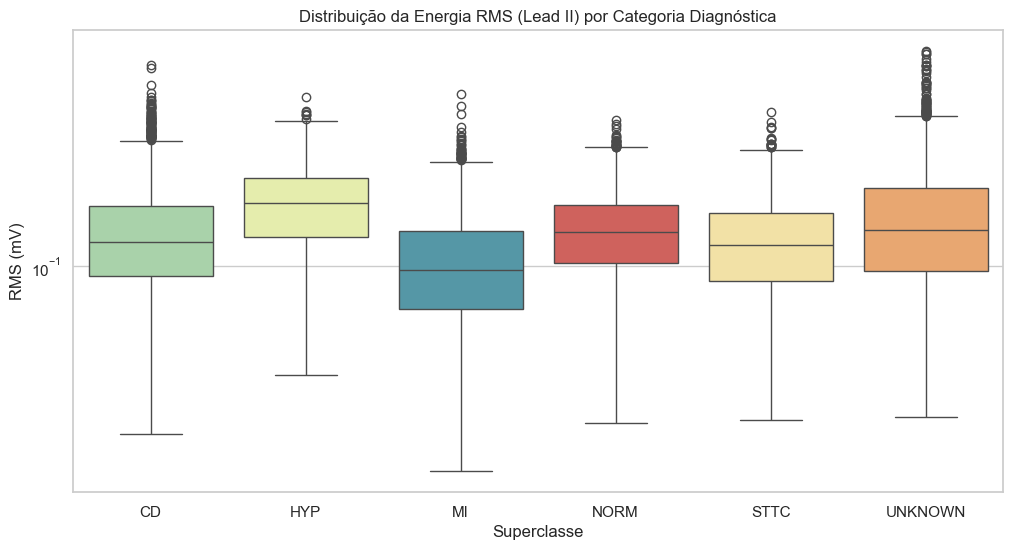

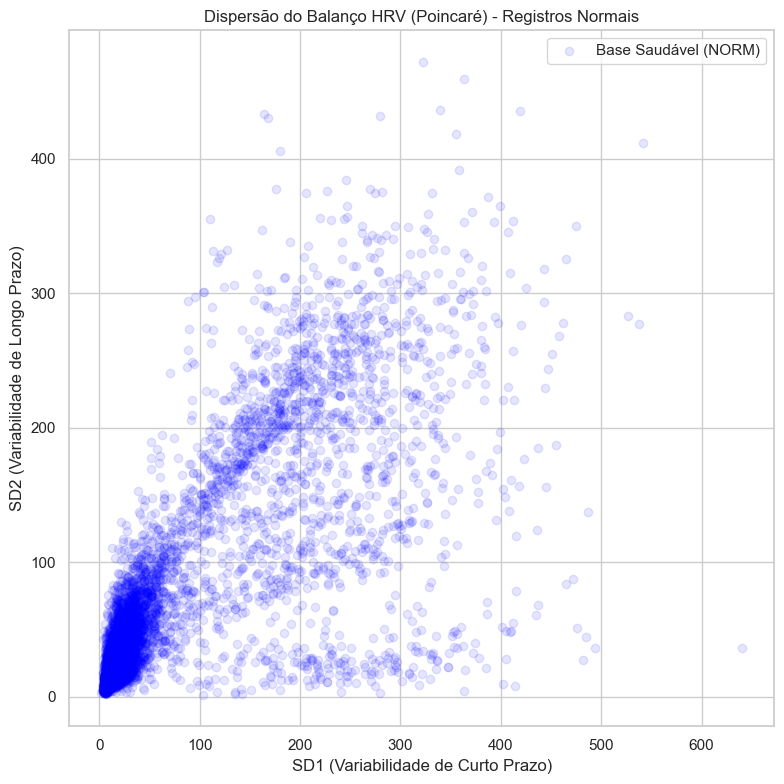

In [18]:
# Plot 1: Distribuição de Energia RMS por Superclasse (Lead II)
df_plot = df_features_raw.copy()

# Correção: Converter string para lista se necessário e extrair o primeiro rótulo
if isinstance(df_plot['diagnostic_superclass'].iloc[0], str):
    import ast
    df_plot['diagnostic_superclass'] = df_plot['diagnostic_superclass'].apply(ast.literal_eval)

df_plot['label'] = df_plot['diagnostic_superclass'].apply(lambda x: x[0] if len(x)>0 else 'UNKNOWN')

plt.figure(figsize=(12, 6))
# Ordenação alfabética para consistência
order = sorted(df_plot['label'].unique())
sns.boxplot(x='label', y='time_rms_II', data=df_plot, hue='label', palette='Spectral', order=order, legend=False)

plt.title('Distribuição da Energia RMS (Lead II) por Categoria Diagnóstica')
plt.yscale('log')
plt.xlabel('Superclasse')
plt.ylabel('RMS (mV)')
plt.savefig(os.path.join(FIGS_DIR, 'box_rms_superclass.png'))
plt.show()

# Plot 2: Poincaré Plot (Exemplo HRV para registros NORM)
plt.figure(figsize=(8, 8))
# Filtragem: Pegamos os dados do registro NORM para representar a base saudável
df_norm = df_plot[df_plot['label'] == 'NORM']

plt.scatter(df_norm['nonlin_sd1'], df_norm['nonlin_sd2'], c='blue', alpha=0.1, label='Base Saudável (NORM)')
plt.xlabel('SD1 (Variabilidade de Curto Prazo)')
plt.ylabel('SD2 (Variabilidade de Longo Prazo)')
plt.title('Dispersão do Balanço HRV (Poincaré) - Registros Normais')
plt.legend()
plt.tight_layout()
plt.show()


---
## Seção 7 — Síntese e Conexão

Neste entregável, consolidamos a transformação dos sinais brutos em um dataset de alta dimensão. A extração cobriu os domínios temporal, espectral, morfológico e não-linear, resultando em uma representação rica da atividade cardíaca.

**Principais Conclusões:**
1.  **Representatividade**: O dataset final contém atributos que capturam tanto a dinâmica global (10s) quanto a morfologia fina dos batimentos (segmentação).
2.  **Integridade**: Foram tratadas as falhas de cálculo (NaNs) em séries RR curtas e garantida a consistência das colunas.
3.  **Próximos Passos**: No **Entregável 7 (Engenharia de Atributos)**, realizaremos a normalização robusta e a criação de features de segunda ordem (razões entre bandas) para refinar a discriminabilidade do conjunto para o Reconhecimento de Padrões.



In [19]:
# Verificação final de sanidade
print(f"Dimensão final do dataset: {df_features_raw.shape}")
print(f"Valores nulos totais: {df_features_raw.isnull().sum().sum()}")
if df_features_raw.isnull().sum().sum() > 0:
    print("Aviso: Existem valores nulos que serão tratados no Entregável 7 (Normalização/Imputação).")



Dimensão final do dataset: (21735, 196)
Valores nulos totais: 14609
Aviso: Existem valores nulos que serão tratados no Entregável 7 (Normalização/Imputação).
